# Proyecto: clasificación de reseñas en español con variantes de BERT

#### Estudiantes: William Suaza - Anderson Trujillo - Bairon Gutierrez
#### Universidad Icesi - Cali - Valle

## Objetivo

La idea de este notebook es utilizar un mismo problema de clasificación de texto y observar qué sucede cuando cambiamos únicamente el modelo BERT utilizado.

Trabajaremos con reseñas de Amazon en español y buscaremos predecir la calificación de **1 a 5 estrellas**. Para que la comparación sea lo más justa posible, los tres experimentos utilizarán:

- El mismo conjunto de entrenamiento de **50.000 reseñas**.
- Cinco clases balanceadas, con **10.000 reseñas por clase**.
- Las mismas particiones de entrenamiento, validación y prueba.
- Los mismos hiperparámetros de entrenamiento.
- Las mismas métricas: **Accuracy, MAE y tiempo de entrenamiento**.
- El mismo procedimiento para construir la matriz de confusión y analizar los errores.

Los modelos que vamos a comparar son:

1. **BETO Cased**: `dccuchile/bert-base-spanish-wwm-cased`: Versión entrenada para idioma español, conserva la diferencia entre mayusculas y minusculas.
2. **BETO Uncased**: `dccuchile/bert-base-spanish-wwm-uncased`: : Versión entrenada para idioma español, no diferencia entre mayusculas y minusculas.
3. **Multilingual BERT**: `bert-base-multilingual-cased`: : Versión entrenada para multiples idiomas.

La intención del ejercicio es experimentar, observar los resultados y entender qué ganamos o qué perdemos con cada alternativa.

## 1. Preparación del entorno

Este notebook está preparado para ejecutarse en **Google Colab** y fue ejecutado con una GPU L4.

Se fijan las versiones principales de Hugging Face para evitar que un cambio futuro en la API modifique el comportamiento del notebook. La instalación se realiza antes de importar las librerías.

In [1]:
# Ejecutar primero en una sesión nueva de Colab con GPU L4.
# Se conserva el PyTorch/CUDA preinstalado por Colab.
import os
import sys
import subprocess
from importlib import metadata

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

REQUISITOS = {
    "transformers": "4.57.1",
    "datasets": "4.3.0",
    "accelerate": "1.11.0",
    "huggingface-hub": "0.36.0",
    "tokenizers": "0.22.1",
}
modulos_cargados = any(
    nombre.split(".")[0] in {"transformers", "datasets", "accelerate", "tokenizers", "huggingface_hub"}
    for nombre in sys.modules
)
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *[f"{paquete}=={version}" for paquete, version in REQUISITOS.items()],
    "scikit-learn>=1.3,<2", "matplotlib>=3.7,<4", "pandas>=2.2,<3",
])
# Este experimento es exclusivamente de texto. Estas dependencias opcionales
# pueden romper la importación de BERT si no coinciden con PyTorch/NumPy.
# Se retiran solo de la sesión de Colab; no se modifica torch ni CUDA.
subprocess.check_call([
    sys.executable, "-m", "pip", "uninstall", "--yes", "--quiet",
    "torchvision", "torchaudio", "librosa",
])
for paquete in REQUISITOS:
    print(f"{paquete}: {metadata.version(paquete)}")
print("Instalación terminada. Reinicia la sesión de Colab una vez y continúa en la siguiente celda.")
if modulos_cargados:
    print("El reinicio es necesario: había librerías importadas antes de la instalación.")

transformers: 4.57.1
datasets: 4.3.0
accelerate: 1.11.0
huggingface-hub: 0.36.0
tokenizers: 0.22.1
Instalación terminada. Reinicia la sesión de Colab una vez y continúa en la siguiente celda.


In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import time
import shutil
import random
import warnings
import json
import tempfile
from importlib import metadata
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import accuracy_score, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

# No ocultamos advertencias de instalación, carga o entrenamiento.
for paquete, version in {
    "transformers": "4.57.1", "datasets": "4.3.0", "accelerate": "1.11.0",
    "huggingface-hub": "0.36.0", "tokenizers": "0.22.1",
}.items():
    if metadata.version(paquete) != version:
        raise RuntimeError(f"Versión inesperada de {paquete}. Ejecuta la primera celda y reinicia la sesión.")
import transformers
if transformers.__version__ != "4.57.1":
    raise RuntimeError("Transformers sigue cargado con otra versión. Reinicia la sesión.")
from packaging.version import Version
if Version(torch.__version__.split("+")[0]) < Version("2.6"):
    raise RuntimeError("Se requiere PyTorch >= 2.6 para cargar los checkpoints .bin de BETO. Usa una sesión Colab actualizada con GPU.")
print("PyTorch:", torch.__version__)
print("CUDA de PyTorch:", torch.version.cuda)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo disponible:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "ADVERTENCIA: no se detectó GPU. El notebook puede ejecutarse en CPU, "
        "pero el entrenamiento de los tres modelos tardará considerablemente más."
    )

PyTorch: 2.11.0+cu128
CUDA de PyTorch: 12.8
Dispositivo disponible: cuda
GPU: NVIDIA L4


## 2. Diseño del experimento

La comparación se construye como un **experimento controlado**: mantenemos constantes los datos y la configuración de entrenamiento y cambiamos el modelo preentrenado.

| Experimento | Modelo | Pregunta que queremos observar |
|---|---|---|
| 1 | BETO Cased | ¿Cómo se comporta un BERT especializado en español conservando mayúsculas y minúsculas? |
| 2 | BETO Uncased | ¿Qué cambia cuando el modelo especializado en español no difeencia entre mayusculas y minusculas? |
| 3 | Multilingual BERT | ¿Qué sucede al utilizar un BERT entrenado para múltiples idiomas en lugar de uno especializado en español? |

Para los tres modelos utilizaremos **fine-tuning completo**. Es decir, no congelaremos el modelo base: permitiremos que sus pesos se ajusten al problema de clasificación de reseñas.

Esta decisión implica modificar los pesos obtenidos durante el preentrenamiento, por lo que existe el riesgo de sobreajuste o de alterar el modelo. Para reducir este riesgo utilizaremos una tasa de aprendizaje baja (2e-5), únicamente dos épocas de entrenamiento y selección del mejor modelo con base en el conjunto de validación.

De esta manera, BETO Cased, BETO Uncased y Multilingual BERT serán sometidos al mismo procedimiento de adaptación, permitiendo comparar bajo condiciones equivalentes qué tan bien cada modelo puede especializarse en la clasificación de reseñas de Amazon en español.


La comparación principal se realizará con:

- **Accuracy:** proporción de reseñas clasificadas exactamente en la estrella correcta.
- **MAE:** distancia promedio, en estrellas, entre la calificación real y la predicha.
- **Tiempo de entrenamiento:** minutos requeridos por el proceso de fine-tuning.

El MAE es especialmente útil en este problema. Confundir una reseña de 5 estrellas con una de 4 no tiene la misma gravedad que confundirla con una de 1 estrella, aunque para Accuracy ambos casos sean simplemente un error.

## 3. Carga del dataset

Utilizaremos el mismo corpus trabajado previamente: **`SetFit/amazon_reviews_multi_es`**.

El dataset ya contiene las particiones `train`, `validation` y `test`. No crearemos una nueva división aleatoria, porque queremos conservar exactamente la misma lógica utilizada en los ejercicios anteriores.

In [2]:
corpus = load_dataset("SetFit/amazon_reviews_multi_es")

for nombre in ("train", "validation", "test"):
    if nombre not in corpus:
        raise ValueError(f"Falta la partición oficial: {nombre}.")
    faltantes = {"text", "label"} - set(corpus[nombre].column_names)
    if faltantes:
        raise ValueError(f"Columnas faltantes en {nombre}: {faltantes}")
    if len(corpus[nombre]) == 0:
        raise ValueError(f"La partición {nombre} está vacía.")
print(corpus)
print("\nColumnas disponibles:", corpus["train"].column_names)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/43.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

Columnas disponibles: ['id', 'text', 'label', 'label_text']


In [3]:
# Convertimos las tres particiones a pandas porque la depuración y el muestreo
# balanceado son más sencillos de revisar de esta manera.

CRUDOS = {
    nombre: corpus[nombre].to_pandas()[["text", "label"]].copy()
    for nombre in ["train", "validation", "test"]
}

for nombre, df in CRUDOS.items():
    print(f"{nombre:10s}: {len(df):,} registros")

train     : 200,000 registros
validation: 5,000 registros
test      : 5,000 registros


## 4. Depuración y construcción del conjunto común

Antes de muestrear las 50.000 reseñas hacemos dos controles sencillos:

1. Eliminamos textos vacíos y textos duplicados dentro de cada partición.
2. Evitamos que una reseña utilizada en validación o prueba vuelva a aparecer en entrenamiento.

Después de esta depuración tomamos **10.000 reseñas de cada una de las cinco clases**. De esta manera el entrenamiento queda balanceado y los tres modelos reciben exactamente los mismos ejemplos.

In [4]:
N_POR_CLASE = 10_000
COLUMNAS = ["text", "label", "estrellas"]


def limpiar(df):
    """Elimina textos vacíos y conserva una sola aparición de cada reseña."""
    df = df.dropna(subset=["text"]).copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    etiquetas = pd.to_numeric(df["label"], errors="coerce")
    if etiquetas.isna().any() or not etiquetas.isin(range(5)).all():
        raise ValueError("El corpus debe contener etiquetas enteras 0–4, sin nulos.")
    df["label"] = etiquetas.astype("int64")
    return df.drop_duplicates(subset="text").reset_index(drop=True)


def preparar(df, n_por_clase=None, excluir=None):
    """
    Prepara una partición.

    - Si se entrega `excluir`, elimina esos textos.
    - Si se entrega `n_por_clase`, realiza un muestreo balanceado.
    - Crea la variable `estrellas` únicamente para facilitar la lectura.
      La etiqueta que utilizará BERT continúa siendo `label` en escala 0-4.
    """
    df = df.copy()

    if excluir is not None:
        df = df[~df["text"].isin(excluir)]

    if df.empty:
        raise ValueError("La partición quedó vacía después de la depuración.")
    if n_por_clase is not None:
        conteos = df["label"].value_counts().reindex(range(5), fill_value=0)
        if (conteos < n_por_clase).any():
            raise ValueError(f"No hay {n_por_clase:,} reseñas por clase: {conteos.to_dict()}")
        # groupby.sample evita depender de cambios de comportamiento de groupby.apply
        # y mantiene el muestreo reproducible con la misma semilla.
        df = (
            df.groupby("label", group_keys=False)
              .sample(n=n_por_clase, random_state=SEED)
        )

    df["estrellas"] = df["label"].astype(int) + 1

    return (
        df.sample(frac=1, random_state=SEED)
          .reset_index(drop=True)[COLUMNAS]
    )


sin_repetir = {
    nombre: limpiar(df)
    for nombre, df in CRUDOS.items()
}

reservados = (
    set(sin_repetir["validation"]["text"])
    | set(sin_repetir["test"]["text"])
)

descartadas = int(
    sin_repetir["train"]["text"].isin(reservados).sum()
)

val_df = preparar(sin_repetir["validation"])
test_df = preparar(sin_repetir["test"])
train_df = preparar(
    sin_repetir["train"],
    n_por_clase=N_POR_CLASE,
    excluir=reservados,
)

CLASES = [1, 2, 3, 4, 5]
NUM_CLASES = len(CLASES)

resumen_depuracion = pd.DataFrame([
    {
        "partición": nombre,
        "original": len(CRUDOS[nombre]),
        "sin_repetidas": len(sin_repetir[nombre]),
        "final": len(final),
    }
    for nombre, final in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df),
    ]
])

display(resumen_depuracion)

print(
    "\nReseñas descartadas del entrenamiento por aparecer "
    f"en validación o prueba: {descartadas:,}"
)

print("\nRegistros por estrella en entrenamiento:")
display(
    train_df["estrellas"]
    .value_counts()
    .sort_index()
    .rename("registros")
    .to_frame()
)

,partición,original,sin_repetidas,final
0,train,200000,198264,50000
1,validation,5000,4995,4995
2,test,5000,4994,4994



Reseñas descartadas del entrenamiento por aparecer en validación o prueba: 117

Registros por estrella en entrenamiento:


,registros
estrellas,
1,10000
2,10000
3,10000
4,10000
5,10000


### Verificación

No queremos descubrir después del entrenamiento que los modelos fueron comparados con conjuntos diferentes.

In [5]:
fuga_val = set(train_df["text"]) & set(val_df["text"])
fuga_test = set(train_df["text"]) & set(test_df["text"])

assert len(train_df) == 50_000, "El entrenamiento no quedó en 50.000 registros."
assert train_df["estrellas"].value_counts().nunique() == 1, "Las clases no quedaron balanceadas."
assert not fuga_val, "Hay textos compartidos entre entrenamiento y validación."
assert not fuga_test, "Hay textos compartidos entre entrenamiento y prueba."
assert train_df["text"].notna().all(), "Hay textos nulos en entrenamiento."
assert set(train_df["label"].unique()) == {0, 1, 2, 3, 4}, "Las etiquetas no son las esperadas."

print("Verificación completada correctamente.")
print(f"Entrenamiento: {len(train_df):,}")
print(f"Validación:    {len(val_df):,}")
print(f"Prueba:        {len(test_df):,}")

# Se conservan las particiones originales de validación y prueba.
# Informamos su posible solapamiento sin cambiar silenciosamente el experimento.
solapamiento_val_test = set(val_df["text"]) & set(test_df["text"])
print(f"Textos compartidos entre validación y prueba: {len(solapamiento_val_test):,}")
if solapamiento_val_test:
    warnings.warn("Validación y prueba comparten textos; considera esta limitación al interpretar las métricas.")
for nombre, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    assert len(df) > 0 and df["text"].notna().all(), f"Textos inválidos en {nombre}."
    assert df["label"].isin(range(5)).all(), f"Etiquetas inválidas en {nombre}."
assert train_df["label"].value_counts().eq(N_POR_CLASE).all()

Verificación completada correctamente.
Entrenamiento: 50,000
Validación:    4,995
Prueba:        4,994
Textos compartidos entre validación y prueba: 9


/tmp/ipykernel_2817/2599101607.py:21: UserWarning: Validación y prueba comparten textos; considera esta limitación al interpretar las métricas.
  warnings.warn("Validación y prueba comparten textos; considera esta limitación al interpretar las métricas.")


## 5. EDA breve del corpus

Para el rpoyecto realizaremos un EDA muy corto y revisaremos:

- El balance de las cinco clases.
- La longitud de las reseñas.
- Algunos ejemplos reales del corpus.

Esto también nos ayuda a justificar una longitud máxima razonable para BERT.

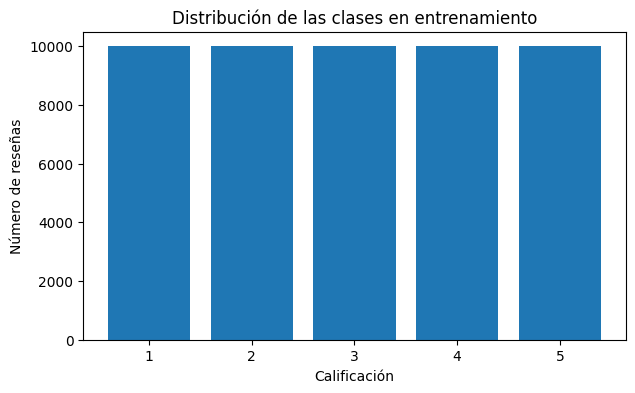

Longitud de las reseñas medida en palabras:


,valor
media,28.0
mediana,22.0
p90,54.0
p95,72.0
p99,123.0
máximo,430.0


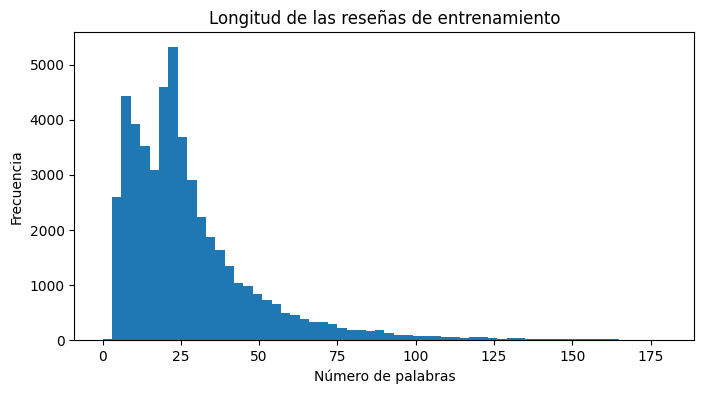

In [6]:
conteo = train_df["estrellas"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(conteo.index.astype(str), conteo.values)
plt.title("Distribución de las clases en entrenamiento")
plt.xlabel("Calificación")
plt.ylabel("Número de reseñas")
plt.show()

longitudes = train_df["text"].str.split().str.len()

resumen_longitud = pd.Series({
    "media": longitudes.mean(),
    "mediana": longitudes.median(),
    "p90": np.percentile(longitudes, 90),
    "p95": np.percentile(longitudes, 95),
    "p99": np.percentile(longitudes, 99),
    "máximo": longitudes.max(),
}).round(1)

print("Longitud de las reseñas medida en palabras:")
display(resumen_longitud.to_frame("valor"))

plt.figure(figsize=(8, 4))
plt.hist(longitudes, bins=60, range=(0, 180))
plt.title("Longitud de las reseñas de entrenamiento")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

In [7]:
# Mostramos una reseña de ejemplo por cada calificación.
ejemplos = (
    train_df.groupby("estrellas", group_keys=False)
    .sample(n=1, random_state=SEED)
    .sort_values("estrellas")[["estrellas", "text"]]
    .reset_index(drop=True)
)

display(ejemplos)

,estrellas,text
0,1,Los canales de TDT algunos emiten en otro idioma
1,2,"Recibida en tiempo y forma, la calidad es mala..."
2,3,Para el uso que le doy las marcas son demasiad...
3,4,Las baterías son totalmente compatibles con la...
4,5,Sinceramente lo cogí porque dije que barato y ...


### Longitud máxima utilizada

Para los tres modelos fijaremos `MAX_LENGTH = 128`.

Observando las palabras calculamos que con esta cantidad de Tokens vamos seguros, mas adelante identificamos que en promedio mas del 97% de las reseñas de caben en este max mength para los modelos utlizando el auto-token.

Lo importante para este experimento es que **los tres modelos tendrán el mismo límite de 128 tokens**. Así evitamos darle a uno de ellos más contexto que a los demás.

## 6. Configuración común de entrenamiento

Tomamos como referencia la lógica del notebook guía de Hugging Face:

- `AutoTokenizer` para cargar el tokenizador correspondiente a cada checkpoint.
- `AutoModelForSequenceClassification` para añadir una cabeza de clasificación de cinco clases.
- `Trainer` y `TrainingArguments` para realizar el fine-tuning.
- 2 épocas.
- Learning rate de `2e-5`.
- Weight decay de `0.01`.

La cabeza de clasificación de cinco clases se crea para nuestro problema. Por eso es normal que Hugging Face informe que algunos pesos del clasificador fueron inicializados nuevamente.

Para que el tiempo sea comparable, mediremos **solamente el tiempo de entrenamiento**. La descarga del modelo, la tokenización y la evaluación no entran en esa medida.

In [9]:
MAX_LENGTH = 128
BATCH_SIZE = 8
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

MODELOS = {
    "BETO Cased": "dccuchile/bert-base-spanish-wwm-cased",
    "BETO Uncased": "dccuchile/bert-base-spanish-wwm-uncased",
    "Multilingual BERT": "bert-base-multilingual-cased",
}

BASE_OUTPUT = "/content/bert_amazon_experimento" if os.path.exists("/content") else "./bert_amazon_experimento"
os.makedirs(BASE_OUTPUT, exist_ok=True)

configuracion = pd.DataFrame({
    "Parámetro": [
        "Máximo de tokens",
        "Batch size",
        "Épocas",
        "Learning rate",
        "Weight decay",
        "Semilla",
    ],
    "Valor": [
        MAX_LENGTH,
        BATCH_SIZE,
        EPOCHS,
        LEARNING_RATE,
        WEIGHT_DECAY,
        SEED,
    ],
})

display(configuracion)

print("\nModelos del experimento:")
for nombre, checkpoint in MODELOS.items():
    print(f"- {nombre}: {checkpoint}")

,Parámetro,Valor
0,Máximo de tokens,128.00000
1,Batch size,8.00000
2,Épocas,2.00000
3,Learning rate,0.00002
4,Weight decay,0.01000
5,Semilla,42.00000



Modelos del experimento:
- BETO Cased: dccuchile/bert-base-spanish-wwm-cased
- BETO Uncased: dccuchile/bert-base-spanish-wwm-uncased
- Multilingual BERT: bert-base-multilingual-cased


In [10]:
from transformers import AutoTokenizer
import numpy as np
import pandas as pd

resultados_longitud = []

for nombre, checkpoint in MODELOS.items():

    tokenizer = AutoTokenizer.from_pretrained(
        checkpoint,
        use_fast=True
    )

    # Tokenizamos sin truncar para conocer la longitud real
    longitudes_tokens = [
        len(tokenizer.encode(texto, truncation=False))
        for texto in train_df["text"]
    ]

    resultados_longitud.append({
        "modelo": nombre,
        "media_tokens": np.mean(longitudes_tokens),
        "mediana_tokens": np.median(longitudes_tokens),
        "p95_tokens": np.percentile(longitudes_tokens, 95),
        "p99_tokens": np.percentile(longitudes_tokens, 99),
        "%_supera_128": 100 * np.mean(
            np.array(longitudes_tokens) > 128
        )
    })

pd.DataFrame(resultados_longitud).round(2)

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (626 > 512). Running this sequence through the model will result in indexing errors


,modelo,media_tokens,mediana_tokens,p95_tokens,p99_tokens,%_supera_128
0,BETO Cased,36.83,29.0,92.0,156.0,1.89
1,BETO Uncased,35.84,29.0,90.0,152.0,1.74
2,Multilingual BERT,42.46,34.0,106.0,180.0,2.82


## 7. Conversión a Hugging Face Dataset

Construimos una única estructura con las tres particiones. Cada experimento parte de este mismo objeto; lo único que se vuelve a hacer es la tokenización, porque cada checkpoint debe utilizar **su propio tokenizador**.

In [11]:
dataset_hf = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "label"]],
        preserve_index=False,
    ),
    "validation": Dataset.from_pandas(
        val_df[["text", "label"]],
        preserve_index=False,
    ),
    "test": Dataset.from_pandas(
        test_df[["text", "label"]],
        preserve_index=False,
    ),
})

dataset_hf

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4995
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4994
    })
})

## 8. Funciones comunes para los tres experimentos

En lugar de copiar tres veces el mismo código, construiremos una sola función. Esto reduce la posibilidad de introducir diferencias accidentales entre los modelos.

La función hará siempre los mismos pasos:

1. Cargar el tokenizador correspondiente.
2. Tokenizar las mismas particiones.
3. Cargar el modelo con una cabeza de cinco clases.
4. Realizar fine-tuning con los mismos hiperparámetros.
5. Evaluar sobre `test`.
6. Calcular Accuracy, MAE y tiempo.
7. Construir la matriz de confusión.
8. Guardar los errores para analizarlos después.
9. Liberar memoria antes de entrenar el siguiente modelo.

In [12]:
def calcular_metricas(eval_pred):
    """
    Métricas utilizadas durante la evaluación de Hugging Face.

    Las etiquetas internas están en escala 0-4. Para Accuracy esto no cambia
    nada. Para MAE tampoco cambia la distancia, pero sumamos 1 para que la
    lectura corresponda directamente a estrellas 1-5.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    pred = np.argmax(logits, axis=-1)

    y_real = labels + 1
    y_pred = pred + 1

    return {
        "accuracy": accuracy_score(y_real, y_pred),
        "mae": mean_absolute_error(y_real, y_pred),
    }


def mostrar_matriz_confusion(nombre_modelo, matriz):
    """Grafica la matriz de confusión de un modelo."""
    fig, ax = plt.subplots(figsize=(6, 6))
    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=CLASES,
    )
    display_cm.plot(ax=ax, values_format="d")
    ax.set_title(f"Matriz de confusión - {nombre_modelo}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    plt.show()


def analizar_errores(nombre_modelo, errores_df, n=8):
    """
    Resume qué tan lejos quedan las predicciones incorrectas y muestra
    algunos de los errores más grandes.
    """
    incorrectos = errores_df[errores_df["error_abs"] > 0].copy()

    resumen = (
        errores_df["error_abs"]
        .value_counts()
        .sort_index()
        .rename_axis("distancia_en_estrellas")
        .rename("n_reseñas")
        .to_frame()
    )
    resumen["porcentaje"] = (
        100 * resumen["n_reseñas"] / len(errores_df)
    ).round(2)

    print(f"\nDistribución de la distancia del error - {nombre_modelo}")
    display(resumen)

    if len(incorrectos) == 0:
        print("El modelo no presentó errores en el conjunto de prueba.")
        return

    ejemplos_error = (
        incorrectos
        .sort_values(
            ["error_abs", "estrellas_reales"],
            ascending=[False, True],
        )
        .head(n)
        [["estrellas_reales", "estrellas_predichas", "error_abs", "text"]]
        .copy()
    )

    ejemplos_error["text"] = ejemplos_error["text"].str.slice(0, 300)

    print(f"\nEjemplos de los errores de mayor distancia - {nombre_modelo}")
    display(ejemplos_error.reset_index(drop=True))


class TrainerConTiempo(Trainer):
    """Descuenta validación y escritura/lectura de checkpoints del cronómetro."""
    tiempo_fuera_entrenamiento = 0.0

    def _medir_fuera(self, funcion, *args, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        inicio = time.perf_counter()
        try:
            return funcion(*args, **kwargs)
        finally:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            self.tiempo_fuera_entrenamiento += time.perf_counter() - inicio

    def evaluate(self, *args, **kwargs):
        return self._medir_fuera(super().evaluate, *args, **kwargs)

    def _save_checkpoint(self, *args, **kwargs):
        return self._medir_fuera(super()._save_checkpoint, *args, **kwargs)

    def _load_best_model(self, *args, **kwargs):
        return self._medir_fuera(super()._load_best_model, *args, **kwargs)


def entrenar_y_evaluar(nombre_modelo, checkpoint):
    """
    Ejecuta un experimento completo.

    Devuelve:
    - Un diccionario con las métricas.
    - La matriz de confusión.
    - Un DataFrame con la predicción de cada reseña de prueba.
    """
    print("=" * 80)
    print("MODELO:", nombre_modelo)
    print("CHECKPOINT:", checkpoint)
    print("=" * 80)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    set_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.cuda.empty_cache()

    trainer = model = tokenized_dataset = tokenizer = None
    output_dir = None
    terminado = False
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            checkpoint,
            use_fast=True,
        )

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.sep_token

        def tokenizar_lote(batch):
            return tokenizer(
                batch["text"],
                truncation=True,
                padding="max_length",
                max_length=MAX_LENGTH,
            )

        print("\nTokenizando las tres particiones...")

        tokenized_dataset = dataset_hf.map(
            tokenizar_lote,
            batched=True,
            batch_size=1_000,
            remove_columns=["text"],
            desc=f"Tokenización - {nombre_modelo}",
        )

        id2label = {
            0: "1 estrella",
            1: "2 estrellas",
            2: "3 estrellas",
            3: "4 estrellas",
            4: "5 estrellas",
        }
        label2id = {valor: llave for llave, valor in id2label.items()}

        model = AutoModelForSequenceClassification.from_pretrained(
            checkpoint,
            num_labels=NUM_CLASES,
            id2label=id2label,
            label2id=label2id,
        )

        model.config.pad_token_id = tokenizer.pad_token_id

        slug = (
            nombre_modelo.lower()
            .replace(" ", "_")
            .replace("/", "_")
        )
        output_dir = tempfile.mkdtemp(prefix=slug + "_", dir=BASE_OUTPUT)

        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=EPOCHS,
            learning_rate=LEARNING_RATE,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            weight_decay=WEIGHT_DECAY,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="accuracy",
            greater_is_better=True,
            save_total_limit=1,
            logging_strategy="steps",
            logging_steps=250,
            report_to="none",
            fp16=torch.cuda.is_available(),
            seed=SEED,
            data_seed=SEED,
            disable_tqdm=False,
            eval_accumulation_steps=32,
            dataloader_num_workers=0,
            dataloader_pin_memory=torch.cuda.is_available(),
        )

        trainer = TrainerConTiempo(
            model=model,
            args=training_args,
            compute_metrics=calcular_metricas,
            train_dataset=tokenized_dataset["train"],
            eval_dataset=tokenized_dataset["validation"],
            processing_class=tokenizer,
        )

        print("\nIniciando fine-tuning...")
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        trainer.tiempo_fuera_entrenamiento = 0.0
        inicio = time.perf_counter()
        trainer.train()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        tiempo_total = time.perf_counter() - inicio
        tiempo_entrenamiento = max(0.0, tiempo_total - trainer.tiempo_fuera_entrenamiento)
        tiempo_minutos = tiempo_entrenamiento / 60

        print("\nEvaluando el mejor checkpoint sobre el conjunto de prueba...")
        pred_test = trainer.predict(tokenized_dataset["test"])

        y_real_0_4 = pred_test.label_ids
        logits_test = pred_test.predictions
        if isinstance(logits_test, tuple):
            logits_test = logits_test[0]
        y_pred_0_4 = np.argmax(logits_test, axis=-1)
        if not np.array_equal(y_real_0_4, test_df["label"].to_numpy()):
            raise ValueError("El orden de las predicciones no coincide con test_df.")

        y_real = y_real_0_4 + 1
        y_pred = y_pred_0_4 + 1

        accuracy = accuracy_score(y_real, y_pred)
        mae = mean_absolute_error(y_real, y_pred)

        matriz = confusion_matrix(
            y_real,
            y_pred,
            labels=CLASES,
        )

        errores_df = test_df[["text", "estrellas"]].copy()
        errores_df = errores_df.rename(
            columns={"estrellas": "estrellas_reales"}
        )
        errores_df["estrellas_predichas"] = y_pred
        errores_df["error_abs"] = (
            errores_df["estrellas_reales"]
            - errores_df["estrellas_predichas"]
        ).abs()

        resultado = {
            "modelo": nombre_modelo,
            "checkpoint": checkpoint,
            "accuracy": float(accuracy),
            "mae": float(mae),
            "tiempo_min": float(tiempo_minutos),
        }

        print("\nResultado en prueba:")
        print(f"Accuracy:                {accuracy:.4f}")
        print(f"MAE:                     {mae:.4f} estrellas")
        print(f"Tiempo de entrenamiento: {tiempo_minutos:.2f} minutos")

        # Guardar cada resultado antes de iniciar el siguiente experimento.
        with open(os.path.join(BASE_OUTPUT, slug + "_metricas.json"), "w", encoding="utf-8") as archivo:
            json.dump(resultado, archivo, ensure_ascii=False, indent=2)
        errores_df.to_csv(os.path.join(BASE_OUTPUT, slug + "_predicciones.csv"), index=False)
        np.save(os.path.join(BASE_OUTPUT, slug + "_matriz.npy"), matriz)

        mostrar_matriz_confusion(nombre_modelo, matriz)
        analizar_errores(nombre_modelo, errores_df)

        terminado = True
        return resultado, matriz, errores_df
    finally:
        del trainer, model, tokenized_dataset, tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        if terminado and output_dir is not None:
            shutil.rmtree(output_dir, ignore_errors=True)
        elif output_dir is not None:
            print("Ejecución interrumpida. Checkpoints conservados en:", output_dir)

## 9. Contenedores de resultados

Guardaremos los resultados por nombre de modelo. Si por algún motivo necesitamos repetir un experimento, el resultado anterior de ese modelo se reemplazará en lugar de duplicarse.

In [13]:
resultados = {}
matrices_confusion = {}
errores_modelos = {}

# Experimento 1 — BETO Cased

Comenzamos con BETO en su variante **cased**. Este modelo fue preentrenado específicamente para español y conserva la información de mayúsculas y minúsculas.

Nuestra pregunta es sencilla: **¿qué desempeño obtenemos cuando utilizamos un BERT especializado en español conservando la capitalización original de las reseñas?**

MODELO: BETO Cased
CHECKPOINT: dccuchile/bert-base-spanish-wwm-cased

Tokenizando las tres particiones...


Tokenización - BETO Cased:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenización - BETO Cased:   0%|          | 0/4995 [00:00<?, ? examples/s]

Tokenización - BETO Cased:   0%|          | 0/4994 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

...


Iniciando fine-tuning...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Mae
1,1.015600,0.983771,0.566166,0.510911
2,0.845400,1.001723,0.571371,0.494494



Evaluando el mejor checkpoint sobre el conjunto de prueba...



Resultado en prueba:
Accuracy:                0.5829
MAE:                     0.4794 estrellas
Tiempo de entrenamiento: 13.73 minutos


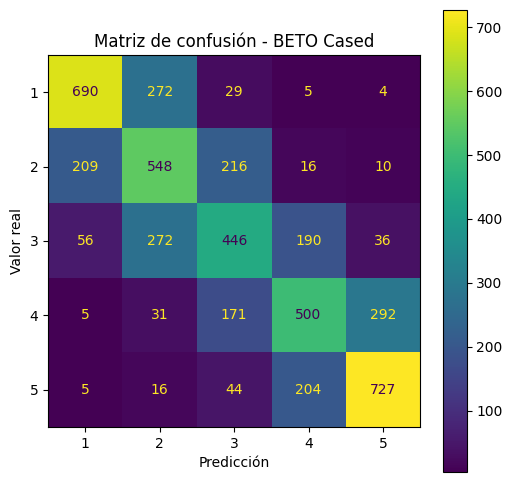


Distribución de la distancia del error - BETO Cased


,n_reseñas,porcentaje
distancia_en_estrellas,,
0,2911,58.29
1,1826,36.56
2,212,4.25
3,36,0.72
4,9,0.18



Ejemplos de los errores de mayor distancia - BETO Cased


,estrellas_reales,estrellas_predichas,error_abs,text
0,1,5,4,Es tal cual lo vi en la fotografía
1,1,5,4,La bombilla se mantiene encendida cuando apaga...
2,1,5,4,COMPRÉ TRES BATERÍAS (2 NEGRAS 1 BLANCA)LAS DO...
3,1,5,4,Ya no lo necesito no pensé que duraría tanto e...
4,5,1,4,"No llegó el paquete, informé al vendedor y tuv..."
5,5,1,4,Magnífico! es el tercero que compro porque por...
6,5,1,4,"3 kindle he tenido, a todos los mismos forros."
7,5,1,4,Me han gustado mucho per estoy descontenta por...


In [14]:
nombre = "BETO Cased"

resultado, matriz, errores = entrenar_y_evaluar(
    nombre,
    MODELOS[nombre],
)

resultados[nombre] = resultado
matrices_confusion[nombre] = matriz
errores_modelos[nombre] = errores

# Experimento 2 — BETO Uncased

Ahora repetimos exactamente el mismo procedimiento con **BETO Uncased**.

La diferencia que queremos estudiar es el tratamiento de mayúsculas y minúsculas. En reseñas de usuarios es frecuente encontrar escritura informal, palabras completamente en mayúsculas o capitalización inconsistente.

MODELO: BETO Uncased
CHECKPOINT: dccuchile/bert-base-spanish-wwm-uncased

Tokenizando las tres particiones...


Tokenización - BETO Uncased:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenización - BETO Uncased:   0%|          | 0/4995 [00:00<?, ? examples/s]

Tokenización - BETO Uncased:   0%|          | 0/4994 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

...


Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Mae
1,1.037200,0.997555,0.555355,0.535335
2,0.861100,1.029140,0.567968,0.500701


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Evaluando el mejor checkpoint sobre el conjunto de prueba...



Resultado en prueba:
Accuracy:                0.5757
MAE:                     0.4874 estrellas
Tiempo de entrenamiento: 13.92 minutos


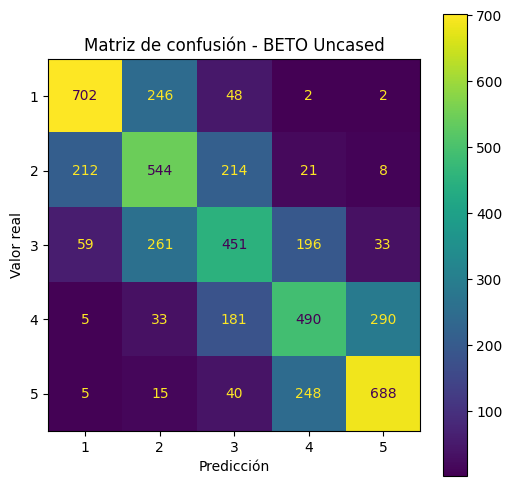


Distribución de la distancia del error - BETO Uncased


,n_reseñas,porcentaje
distancia_en_estrellas,,
0,2875,57.57
1,1848,37.00
2,234,4.69
3,30,0.60
4,7,0.14



Ejemplos de los errores de mayor distancia - BETO Uncased


,estrellas_reales,estrellas_predichas,error_abs,text
0,1,5,4,Es tal cual lo vi en la fotografía
1,1,5,4,"El producto perfecto el envío pésimo, llego ta..."
2,5,1,4,"No llegó el paquete, informé al vendedor y tuv..."
3,5,1,4,Han quedado brutales.
4,5,1,4,Magnífico! es el tercero que compro porque por...
5,5,1,4,el problema es que amazon solo deje comprar 5 ...
6,5,1,4,Lo e devuelto pues me equivoqué en tamaño era ...
7,1,4,3,Lo voy a utilizar para regalo de niñas de comu...


In [15]:
nombre = "BETO Uncased"

resultado, matriz, errores = entrenar_y_evaluar(
    nombre,
    MODELOS[nombre],
)

resultados[nombre] = resultado
matrices_confusion[nombre] = matriz
errores_modelos[nombre] = errores

# Experimento 3 — Multilingual BERT

Finalmente utilizamos **Multilingual BERT (mBERT)**.

A diferencia de BETO, este modelo no está especializado únicamente en español. Fue preentrenado para trabajar con múltiples idiomas. La pregunta aquí es diferente: **¿qué tanto cambia el desempeño cuando utilizamos un modelo multilingüe en una tarea completamente en español?**

MODELO: Multilingual BERT
CHECKPOINT: bert-base-multilingual-cased

Tokenizando las tres particiones...


Tokenización - Multilingual BERT:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenización - Multilingual BERT:   0%|          | 0/4995 [00:00<?, ? examples/s]

Tokenización - Multilingual BERT:   0%|          | 0/4994 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Mae
1,1.082500,1.038346,0.541942,0.559159
2,0.933300,1.036854,0.545145,0.536737



Evaluando el mejor checkpoint sobre el conjunto de prueba...



Resultado en prueba:
Accuracy:                0.5667
MAE:                     0.5102 estrellas
Tiempo de entrenamiento: 17.13 minutos


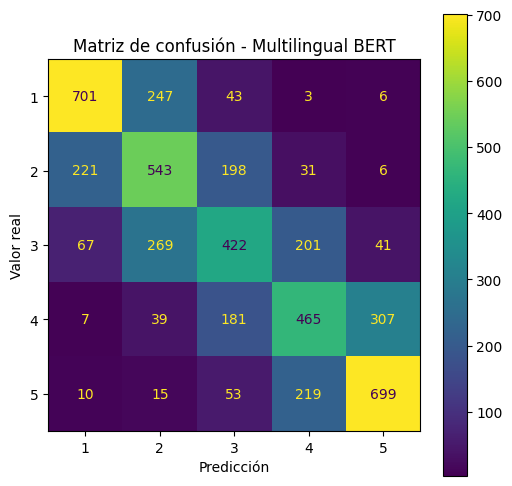


Distribución de la distancia del error - Multilingual BERT


,n_reseñas,porcentaje
distancia_en_estrellas,,
0,2830,56.67
1,1843,36.90
2,274,5.49
3,31,0.62
4,16,0.32



Ejemplos de los errores de mayor distancia - Multilingual BERT


,estrellas_reales,estrellas_predichas,error_abs,text
0,1,5,4,"Es fantástica, ya me estallo dos veces en la m..."
1,1,5,4,Abierto y manipulado. No era estanco.
2,1,5,4,Lo voy a utilizar para regalo de niñas de comu...
3,1,5,4,Es tal cual lo vi en la fotografía
4,1,5,4,Me ha encantado!. Las dos pizarras son magnéti...
5,1,5,4,EL TELEFONO IMPOSIBLE DE FUNCIONAR INSTRUCCION...
6,5,1,4,"No llegó el paquete, informé al vendedor y tuv..."
7,5,1,4,El producto es buenísimo y a la primera vez qu...


In [16]:
nombre = "Multilingual BERT"

resultado, matriz, errores = entrenar_y_evaluar(
    nombre,
    MODELOS[nombre],
)

resultados[nombre] = resultado
matrices_confusion[nombre] = matriz
errores_modelos[nombre] = errores

## 10. Comparación final

Ahora sí reunimos los resultados de los tres experimentos, Vamos a observar conjuntamente:

- **Accuracy:** qué tan frecuentemente acierta exactamente la calificación.
- **MAE:** qué tan lejos queda cuando se equivoca.
- **Tiempo:** cuánto costó entrenarlo bajo el mismo entorno.

In [17]:
if not resultados:
    raise RuntimeError("Todavía no hay resultados. Ejecuta los experimentos 1, 2 y 3.")

resultados_df = pd.DataFrame(resultados.values()).copy()

if len(resultados_df) != 3:
    print(
        f"ADVERTENCIA: hay resultados de {len(resultados_df)} de los 3 modelos. "
        "Ejecuta los experimentos faltantes antes de cerrar la comparación."
    )

columnas_mostrar = [
    "modelo",
    "accuracy",
    "mae",
    "tiempo_min",
]

comparacion = resultados_df[columnas_mostrar].copy()
comparacion["accuracy"] = comparacion["accuracy"].round(4)
comparacion["mae"] = comparacion["mae"].round(4)
comparacion["tiempo_min"] = comparacion["tiempo_min"].round(2)

display(comparacion)

,modelo,accuracy,mae,tiempo_min
0,BETO Cased,0.5829,0.4794,13.73
1,BETO Uncased,0.5757,0.4874,13.92
2,Multilingual BERT,0.5667,0.5102,17.13


## 11. Comparación del patrón de errores

El Accuracy nos dice cuántas veces acertamos; el MAE nos dice qué tan lejos quedamos. Sin embargo, todavía podemos aprender más revisando los errores concretos.

Aquí compararemos:

- Cuántas predicciones quedaron a una estrella de distancia.
- Cuántas quedaron a dos, tres o cuatro estrellas.
- Qué reseñas produjeron los errores más grandes.

No buscamos "justificar" todos los errores del modelo. Algunos textos son ambiguos, mezclan aspectos positivos y negativos o simplemente contienen poca información. Lo importante es identificar patrones y reconocer las limitaciones observadas.

In [20]:
if not errores_modelos:
    raise RuntimeError("Ejecuta al menos un experimento antes de comparar los errores.")

resumen_errores_modelos = []

for nombre_modelo, df_errores in errores_modelos.items():
    conteo_error = df_errores["error_abs"].value_counts().sort_index()

    for distancia in range(5):
        resumen_errores_modelos.append({
            "modelo": nombre_modelo,
            "distancia_en_estrellas": distancia,
            "n_reseñas": int(conteo_error.get(distancia, 0)),
            "porcentaje": 100 * float(conteo_error.get(distancia, 0)) / len(df_errores),
        })

resumen_errores_df = pd.DataFrame(resumen_errores_modelos)

display(
    resumen_errores_df
    .pivot(
        index="modelo",
        columns="distancia_en_estrellas",
        values="porcentaje",
    )
    .round(2)
    .rename(columns={
        0: "0 estrellas",
        1: "1 estrella",
        2: "2 estrellas",
        3: "3 estrellas",
        4: "4 estrellas",
    })
)

distancia_en_estrellas,0 estrellas,1 estrella,2 estrellas,3 estrellas,4 estrellas
modelo,,,,,
BETO Cased,58.29,36.56,4.25,0.72,0.18
BETO Uncased,57.57,37.00,4.69,0.60,0.14
Multilingual BERT,56.67,36.90,5.49,0.62,0.32


## 12. Conclusiones del Proyecto
Los tres modelos lograron resultados relativamente cercanos, pero BETO Cased presentó el mejor desempeño general, con un Accuracy de 58,29 %, un MAE de 0,4794 estrellas y el menor tiempo de entrenamiento, 13,73 minutos.

La diferencia entre BETO Cased y BETO Uncased fue pequeña, aunque consistente a favor de la versión Cased. Esto sugiere que conservar la información de mayúsculas y minúsculas puede aportar una señal adicional en este tipo de reseñas, aunque no parece ser un factor determinante por sí solo.

Multilingual BERT obtuvo el menor desempeño y el mayor tiempo de entrenamiento. En este caso, un modelo especializado en español resultó más conveniente que uno multilingüe para una tarea completamente en español, lo cual era esperado.

Finalmente, el análisis de errores mostró que la mayoría de las equivocaciones se producen entre clases cercanas. En BETO Cased, aproximadamente el 95 % de las predicciones fueron correctas o quedaron a una sola estrella de distancia, lo que permite concluir que el modelo captura razonablemente bien la valoración general de las reseñas, aun cuando no siempre acierte exactamente la calificación. modelos **dentro de esta misma ejecución**, no como un benchmark universal.

En adición se observa que algunos errores en Beto-Cased fueron en realidad errores de la logica humana, reseñas muy malas calidicadas como 5 estrellas y viceversa.